# 07 — Comparación controlada de cinco filtros FBP

## Objetivo

Reproducir las veinte reconstrucciones del Hito 1 ampliado variando solo el filtro.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Para cada una de las cuatro condiciones fijar un único sinograma y cambiar filter_name entre Ramp, Shepp–Logan, Cosine, Hamming y Hann. Mantener theta, tamaño, circle=False e interpolación lineal.

**Procedencia:** tcia_comparacion_filtros_fbp.ipynb; Resultados_TCIA.pptx, diapositivas 12–16; alcance actualizado confirmado por el usuario; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.io import save_table
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

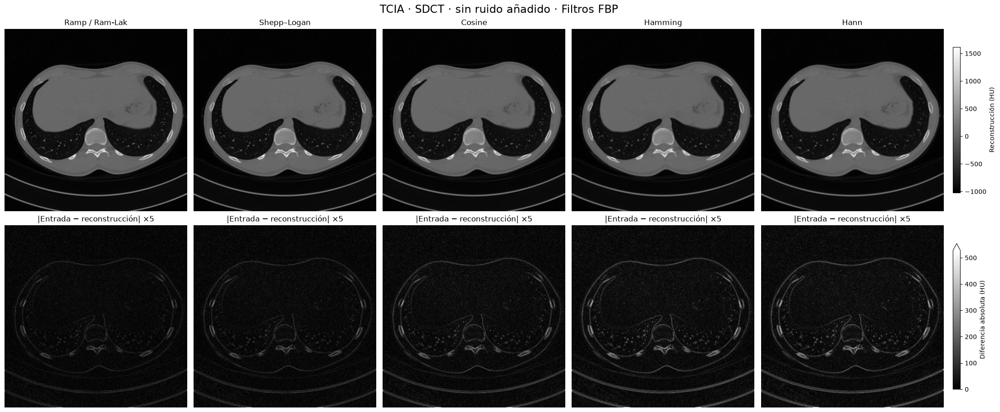

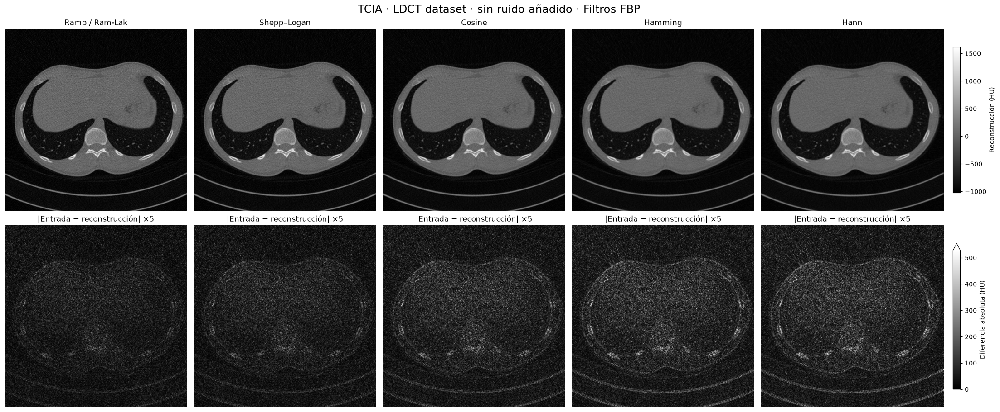

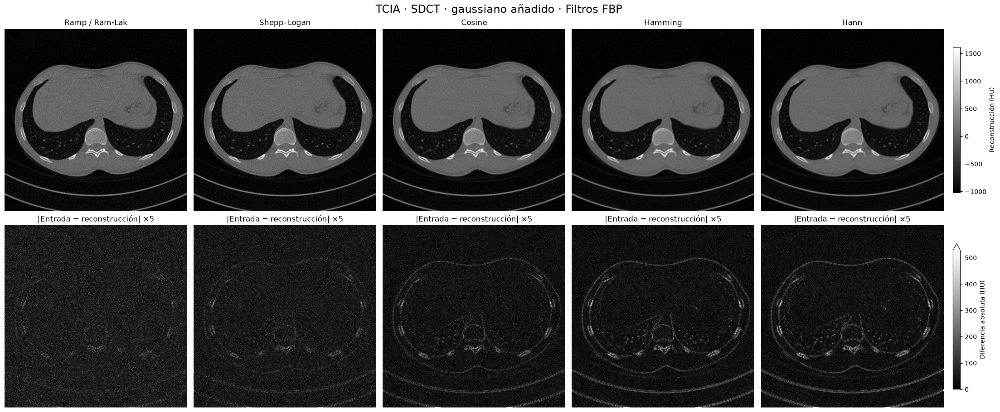

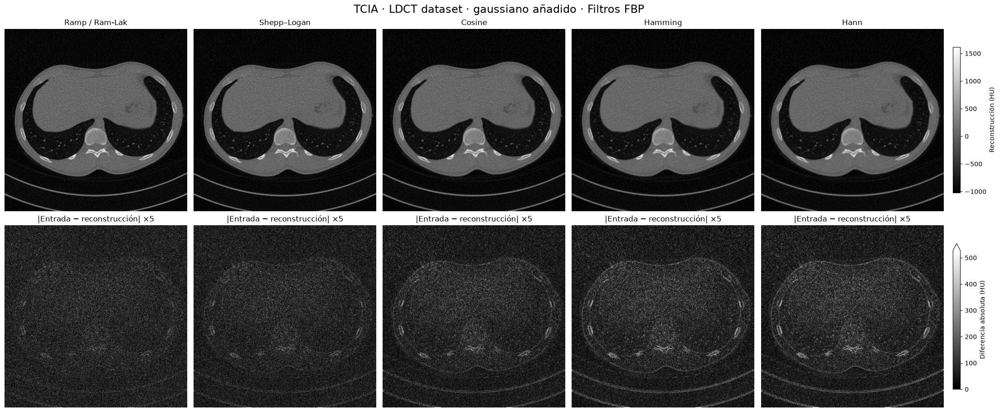

In [2]:
from src.experiments import gaussian_conditions, reconstruct_conditions
from src.filters import FILTERS
from src.visualization import plot_filter_comparison
pair = prepare_pair(config)
conditions = gaussian_conditions(pair, config)
by_filter = {f: reconstruct_conditions(pair, conditions, f) for f in FILTERS}
rows = []
for index, condition in enumerate(conditions):
    cases = [by_filter[f][index] for f in FILTERS]
    fig = plot_filter_comparison(cases, pair['scale'], config['visual_amplification'])
    finish_figure(fig, output_path('figures', '07_filters_' + condition['case'] + '.png'))
    rows.extend(dict(case=c['case'], filter=c['filter_name'], MAE_HU=c['MAE_HU'],
                     RMSE_HU=c['RMSE_HU'], MAX_HU=c['MAX_HU']) for c in cases)

In [3]:
show_table(rows)
save_table(rows, output_path('tables', '07_filters.csv'))

case,filter,MAE_HU,RMSE_HU,MAX_HU
sdct_sin_ruido,ramp,22.9248,31.8897,355.433
sdct_sin_ruido,shepp-logan,25.409,36.0934,412.725
sdct_sin_ruido,cosine,31.0153,45.1744,539.33
sdct_sin_ruido,hamming,35.0974,52.6584,631.508
sdct_sin_ruido,hann,36.2997,54.6384,656.95
ldct_sin_ruido,ramp,53.3041,68.8989,446.964
ldct_sin_ruido,shepp-logan,58.0857,75.494,509.394
ldct_sin_ruido,cosine,69.3867,90.5787,637.565
ldct_sin_ruido,hamming,76.0739,99.6659,753.973
ldct_sin_ruido,hann,78.4178,102.789,783.302


## Observaciones

Cada columna recibe exactamente el mismo sinograma de su condición, incluida la misma realización de ruido. Las métricas HU comparan cada reconstrucción con su propia entrada y no seleccionan automáticamente un filtro universal. La atenuación de altas frecuencias modifica el equilibrio entre granulado y detalle.